# XGBoost — Model Evaluation

Rigorous, honest evaluation of the hotspot classifier: cross-validation, baselines, ROC/PR curves, permutation + SHAP interpretability, and a PCA view of the districts.


In [7]:

!pip install shap --quiet


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, auc
)


## Methodology note

The `hotspot_label` is the top 30% of districts by the survey-weighted composite score, which is a
weighted sum of the same 8 features used as inputs. The XGBoost model therefore **reproduces a known
business scoring rule** and reports **feature importance** — it does not predict an external outcome,
so strong test metrics are expected and are **not** evidence of predictive skill. All metrics are
reported on the held-out test split (and via cross-validation). The baselines below make this explicit:
thresholding the raw score reproduces the label perfectly *by construction*.


In [10]:
# Load data  --  set DATA_PATH to wherever your pipeline wrote the dataset
DATA_PATH = "/content/drive/MyDrive/dataset/FINAL_DATASET.csv"   # Colab; or "../data/Final_data.csv" locally
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (165, 21)


,area_id,avg_sale_price,avg_sale_value,transaction_count,parking_score,metro_score,mall_score,avg_rent,contract_count,rental_yield,...,transaction_count_norm,parking_score_norm,rental_yield_norm,avg_rent_norm,contract_count_norm,metro_score_norm,mall_score_norm,hotspot_score_raw,hotspot_score,rank
0,230.0,5143.045255,1.593337e+06,1473,0.000000,0.935506,0.000000,25100.185100,11297,0.015753,...,0.010776,0.000000,0.107139,0.003177,0.090076,0.935506,0.000000,0.136035,21.653838,129
1,231.0,9686.377121,1.188933e+07,733,0.000000,0.961801,0.156889,75793.572191,5938,0.006375,...,0.005359,0.000000,0.043304,0.009859,0.047343,0.961801,0.156889,0.150003,23.895052,128
2,232.0,7309.106103,2.817807e+06,9952,0.235129,0.971865,0.971865,199651.961889,397,0.070854,...,0.072849,0.235298,0.482191,0.026186,0.003158,0.971865,0.971865,0.339938,54.370460,45
3,233.0,9927.209538,2.645607e+06,2834,0.000000,0.982357,0.524700,22897.687917,48705,0.008655,...,0.020740,0.000000,0.058824,0.002887,0.388374,0.982357,0.524700,0.242075,38.668207,104
4,234.0,7744.678114,6.808329e+06,599,0.000000,0.814691,0.716194,71716.020395,19891,0.010534,...,0.004378,0.000000,0.071611,0.009322,0.158606,0.814691,0.716194,0.216804,34.613428,117


In [11]:
# Create hotspot label (top 30% of the survey score)
threshold = df['hotspot_score'].quantile(0.70)
df['hotspot_label'] = (df['hotspot_score'] >= threshold).astype(int)
print(f"Threshold (70th pct): {threshold:.2f}")
df['hotspot_label'].value_counts()


Threshold (70th pct): 51.79


,count
hotspot_label,
0,115
1,50


In [12]:
# Features / target
features = ['avg_sale_price','rental_yield','transaction_count','contract_count',
            'avg_rent','mall_score','metro_score','parking_score']
X = df[features]
y = df['hotspot_label']


In [13]:
# Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])
print("train hotspot rate: %.1f%% | test hotspot rate: %.1f%%" %
      (100*y_train.mean(), 100*y_test.mean()))


train: 132 | test: 33
train hotspot rate: 30.3% | test hotspot rate: 30.3%


In [14]:
# Train XGBoost  --  scale_pos_weight handles the ~30/70 class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

from sklearn.model_selection import RandomizedSearchCV
xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                    scale_pos_weight=scale_pos_weight, random_state=42)
param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [3,4,5,6],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.8,0.9,1.0],
}
search = RandomizedSearchCV(xgb, param_grid, n_iter=20, scoring='f1',
                            cv=5, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_xgb = search.best_estimator_
print("Best params:", search.best_params_)


scale_pos_weight = 2.300
Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}


In [15]:
# Test-set predictions
xgb_pred = best_xgb.predict(X_test)
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]


In [16]:
# Core test-set metrics
metrics = {
    'Accuracy':  accuracy_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall':    recall_score(y_test, xgb_pred),
    'F1':        f1_score(y_test, xgb_pred),
    'AUC':       roc_auc_score(y_test, xgb_prob),
}
for k, v in metrics.items():
    print(f"{k:<10} {v:.4f}")


Accuracy   0.9697
Precision  1.0000
Recall     0.9000
F1         0.9474
AUC        0.9739


              precision    recall  f1-score   support

 Not Hotspot       0.96      1.00      0.98        23
     Hotspot       1.00      0.90      0.95        10

    accuracy                           0.97        33
   macro avg       0.98      0.95      0.96        33
weighted avg       0.97      0.97      0.97        33



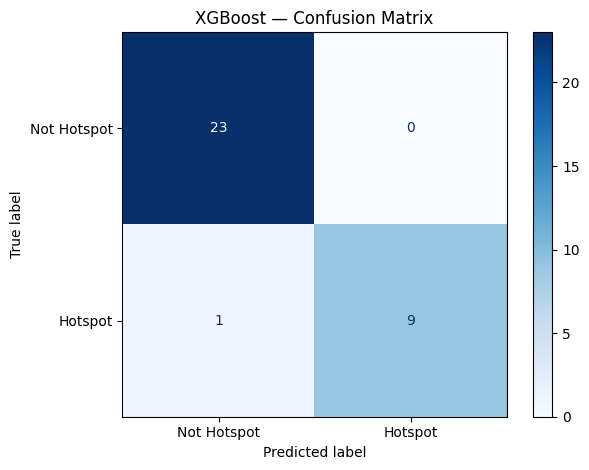

In [17]:
# Classification report + confusion matrix
print(classification_report(y_test, xgb_pred, target_names=['Not Hotspot','Hotspot']))
cm = confusion_matrix(y_test, xgb_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Hotspot','Hotspot']).plot(cmap='Blues')
plt.title("XGBoost — Confusion Matrix"); plt.tight_layout(); plt.show()


## 1. Cross-validation (stability)

A single 20% split is only ~33 districts, so one or two errors swing the metrics. Stratified 5-fold CV
on the full dataset shows whether performance is stable rather than lucky.


In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(best_xgb, X, y, cv=skf, scoring='roc_auc')
cv_f1  = cross_val_score(best_xgb, X, y, cv=skf, scoring='f1')
print("CV AUC : %.3f ± %.3f" % (cv_auc.mean(), cv_auc.std()))
print("CV F1  : %.3f ± %.3f" % (cv_f1.mean(),  cv_f1.std()))


CV AUC : 0.977 ± 0.017
CV F1  : 0.883 ± 0.050


## 2. Baselines — "compared to what?"

- **Most-frequent dummy**: the floor any model must beat.
- **Raw-score threshold**: thresholding `hotspot_score` itself. It reproduces the label *perfectly by
  construction* (AUC ≈ 1.0) — this is the honest proof that the task is rule-reconstruction, not
  out-of-sample prediction.


In [19]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])

raw_auc = roc_auc_score(y_test, df.loc[X_test.index, 'hotspot_score'])

print(f"Most-frequent dummy : accuracy {dummy_acc:.3f} | AUC {dummy_auc:.3f}")
print(f"Raw-score threshold : AUC {raw_auc:.3f}  (≈1.0 by construction)")
print(f"XGBoost             : accuracy {metrics['Accuracy']:.3f} | AUC {metrics['AUC']:.3f}")


Most-frequent dummy : accuracy 0.697 | AUC 0.500
Raw-score threshold : AUC 1.000  (≈1.0 by construction)
XGBoost             : accuracy 0.970 | AUC 0.974


## 3. ROC and Precision–Recall curves

PR is the more honest curve here because the positive class is only ~30%.


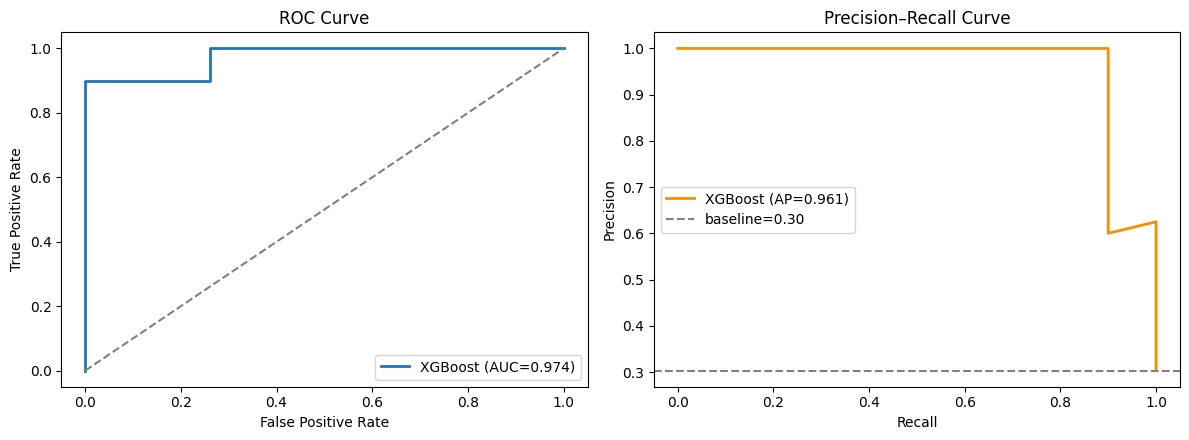

In [20]:
fpr, tpr, _ = roc_curve(y_test, xgb_prob)
prec, rec, _ = precision_recall_curve(y_test, xgb_prob)
roc_auc_v, pr_auc_v = auc(fpr, tpr), auc(rec, prec)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(fpr, tpr, lw=2, label=f"XGBoost (AUC={roc_auc_v:.3f})")
ax[0].plot([0,1],[0,1],'--',color='grey'); ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate"); ax[0].set_title("ROC Curve"); ax[0].legend()
ax[1].plot(rec, prec, lw=2, color='darkorange', label=f"XGBoost (AP={pr_auc_v:.3f})")
ax[1].axhline(y_test.mean(), ls='--', color='grey', label=f"baseline={y_test.mean():.2f}")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision–Recall Curve"); ax[1].legend()
plt.tight_layout(); plt.show()


## 4. Feature importance — gain, permutation, and SHAP

Built-in gain importance is fast but biased; permutation importance (measured on the test set) and
SHAP are more trustworthy. Agreement across all three is a good sign.


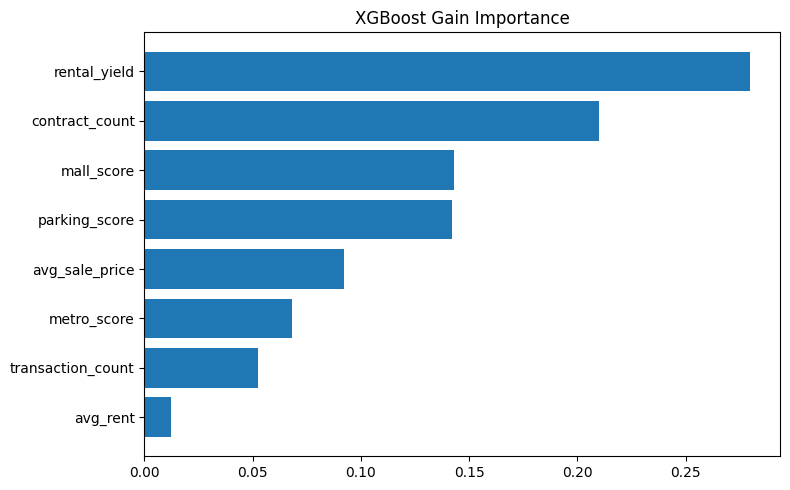

In [21]:
# (a) built-in gain importance
gain = (pd.DataFrame({'Feature': features, 'Gain': best_xgb.feature_importances_})
        .sort_values('Gain'))
plt.figure(figsize=(8,5)); plt.barh(gain['Feature'], gain['Gain'])
plt.title("XGBoost Gain Importance"); plt.tight_layout(); plt.show()


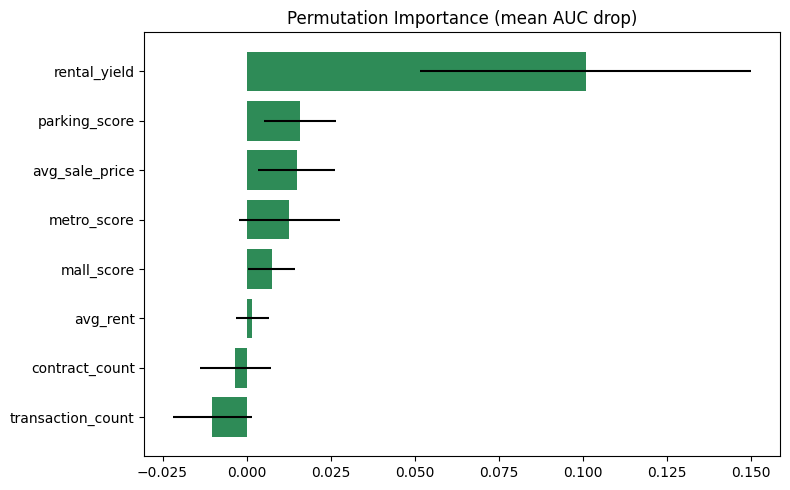

,Feature,Importance,Std
1,rental_yield,0.100870,0.049195
7,parking_score,0.015942,0.010729
0,avg_sale_price,0.014928,0.011431
6,metro_score,0.012754,0.015017
5,mall_score,0.007536,0.007005
4,avg_rent,0.001739,0.004842
3,contract_count,-0.003333,0.010452
2,transaction_count,-0.010145,0.011630


In [22]:
# (b) permutation importance (test set, AUC drop)
perm = permutation_importance(best_xgb, X_test, y_test, n_repeats=30,
                              random_state=42, scoring='roc_auc')
pi = (pd.DataFrame({'Feature': features,
                    'Importance': perm.importances_mean,
                    'Std': perm.importances_std})
      .sort_values('Importance'))
plt.figure(figsize=(8,5))
plt.barh(pi['Feature'], pi['Importance'], xerr=pi['Std'], color='seagreen')
plt.title("Permutation Importance (mean AUC drop)"); plt.tight_layout(); plt.show()
pi.sort_values('Importance', ascending=False)


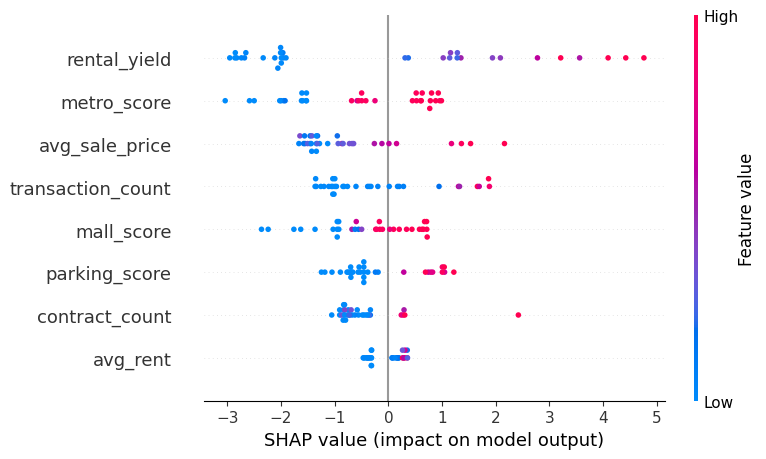

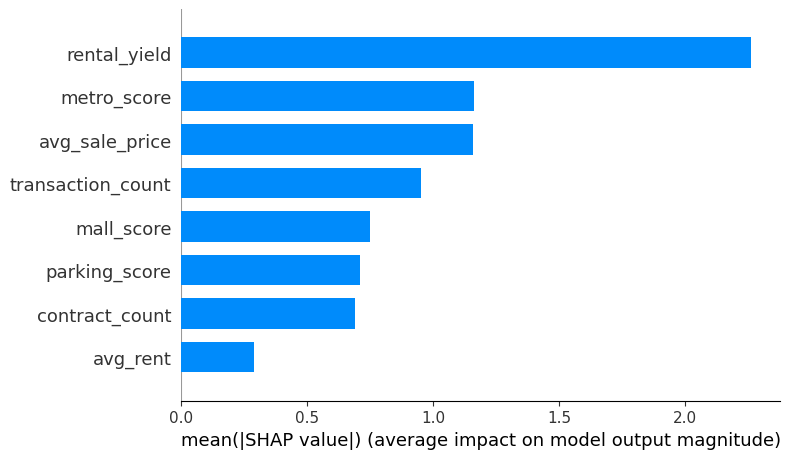

In [23]:
# (c) SHAP values
try:
    import shap
    explainer = shap.TreeExplainer(best_xgb)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, feature_names=features, show=True)
    shap.summary_plot(shap_values, X_test, feature_names=features, plot_type='bar', show=True)
except Exception as e:
    print("SHAP not available — run `!pip install shap`. Skipping. (", e, ")")


## 5. District map in 2D (PCA)

PCA compresses the 8 features to 2 dimensions so we can see how hotspots and K-Means segments sit in
feature space.


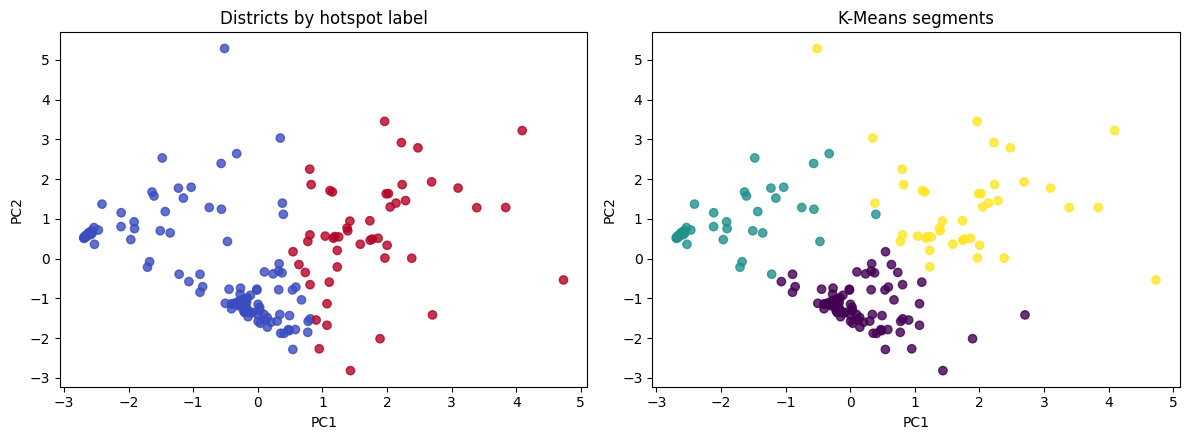

In [24]:
Xs = StandardScaler().fit_transform(X)
pcs = PCA(n_components=2, random_state=42).fit_transform(Xs)
clusters = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(Xs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sc0 = ax[0].scatter(pcs[:,0], pcs[:,1], c=y, cmap='coolwarm', alpha=.8)
ax[0].set_title("Districts by hotspot label"); ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")
ax[1].scatter(pcs[:,0], pcs[:,1], c=clusters, cmap='viridis', alpha=.8)
ax[1].set_title("K-Means segments"); ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()


## 6. Summary table


In [25]:
summary = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1','AUC (test)','AUC (5-fold CV)','F1 (5-fold CV)'],
    'XGBoost': [metrics['Accuracy'], metrics['Precision'], metrics['Recall'], metrics['F1'],
                metrics['AUC'], f"{cv_auc.mean():.3f} ± {cv_auc.std():.3f}",
                f"{cv_f1.mean():.3f} ± {cv_f1.std():.3f}"],
})
baselines = pd.DataFrame({
    'Baseline': ['Most-frequent dummy','Raw-score threshold'],
    'AUC': [round(dummy_auc,3), round(raw_auc,3)],
})
print("=== Model performance ===")
display(summary)
print("=== Baselines ===")
display(baselines)


=== Model performance ===


,Metric,XGBoost
0,Accuracy,0.969697
1,Precision,1.0
2,Recall,0.9
3,F1,0.947368
4,AUC (test),0.973913
5,AUC (5-fold CV),0.977 ± 0.017
6,F1 (5-fold CV),0.883 ± 0.050


=== Baselines ===


,Baseline,AUC
0,Most-frequent dummy,0.5
1,Raw-score threshold,1.0


## 7. Interpretation

- **High but expected.** Test AUC and cross-validated AUC are both strong; this is anticipated because
  the label is derived from the same features (see methodology note). The dummy baseline (AUC ≈ 0.5)
  and the raw-score baseline (AUC ≈ 1.0) bracket the result and confirm the task is *rule
  reconstruction*, not external prediction.
- **What drives the score.** Gain, permutation, and SHAP should broadly agree on the top features
  (typically rent / yield / proximity). Permutation + SHAP are the more reliable rankings.
- **Where it errs.** The confusion matrix shows misses concentrate on borderline mid-tier districts
  near the 70th-percentile cutoff — sensible, since those are genuinely ambiguous.
- **Limitation.** A truly predictive evaluation needs an external target (next-period rent growth,
  occupancy, business survival), which this dataset does not contain. See the README *Limitations*.


In [26]:
# Save the trained model
joblib.dump(best_xgb, 'xgboost_hotspot_model.pkl')
print("Saved xgboost_hotspot_model.pkl")


Saved xgboost_hotspot_model.pkl
